In [2]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight 
from tensorflow.keras.utils import to_categorical
from ydata_profiling import ProfileReport
from tensorflow.keras.metrics import F1Score

In [3]:
df_heart = pd.read_csv('diabetes_balanced.csv')

In [4]:
df_heart.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [5]:
df_heart.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
717,10,94.000000,72.000000,18.00000,125.000000,23.100000,0.59500,56,0
557,8,110.000000,76.000000,29.00000,125.000000,27.800000,0.23700,58,0
65,5,99.000000,74.000000,27.00000,125.000000,29.000000,0.20300,32,0
56,7,187.000000,68.000000,39.00000,304.000000,37.700000,0.25400,41,1
42,7,106.000000,92.000000,18.00000,125.000000,22.700000,0.23500,48,0
730,3,130.000000,78.000000,23.00000,79.000000,28.400000,0.32300,34,1
960,5,162.663405,61.303327,27.04501,489.078278,34.209002,0.72727,37,1
617,2,68.000000,62.000000,13.00000,15.000000,20.100000,0.25700,23,0
642,6,147.000000,80.000000,29.00000,125.000000,29.500000,0.17800,50,1
657,1,120.000000,80.000000,48.00000,200.000000,38.900000,1.16200,41,0


In [6]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   int64  
 8   Outcome                   1000 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 70.4 KB


In [7]:
df_heart.Outcome.value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

In [8]:
X=df_heart.drop('Outcome',axis=1)
y=df_heart['Outcome']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [10]:
model = Sequential([
    Dense(64, activation='relu', kernel_initializer='he_normal', input_shape=(8,)),
    Flatten(),
    Dropout(0.2),
    BatchNormalization(),   
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    BatchNormalization(),
    Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\.conda\envs\AItwo\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 192 (768.00 B)

In [11]:
history = model.fit(X_train, y_train, epochs=100,validation_data=(X_test, y_test), batch_size=32)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5275 - loss: 0.8740 - val_accuracy: 0.6100 - val_loss: 0.6629
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6650 - loss: 0.6265 - val_accuracy: 0.7000 - val_loss: 0.5758
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7025 - loss: 0.5884 - val_accuracy: 0.7150 - val_loss: 0.5354
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7225 - loss: 0.5449 - val_accuracy: 0.7300 - val_loss: 0.5094
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7237 - loss: 0.5761 - val_accuracy: 0.7600 - val_loss: 0.4874
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7287 - loss: 0.5543 - val_accuracy: 0.7500 - val_loss: 0.4788
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7450 - loss: 0.5245 - val_accuracy: 0.7700 - val_loss: 0.4652
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7588 - loss: 0.5009 - val_accuracy: 0.765

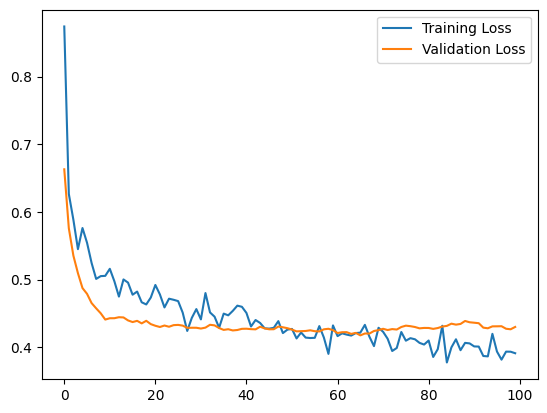

In [12]:
%matplotlib inline
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.show()

In [13]:
confusion_matri = confusion_matrix(y_test, model.predict(X_test).round())
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matri)
print(classification_report(y_test, model.predict(X_test).round()))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       100
           1       0.82      0.84      0.83       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200

